<a href="https://colab.research.google.com/github/ellenyifang2011/sea_level/blob/main/src/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sea Level Project**

In [1]:
import sys
import sklearn
from packaging import version

print("Welcome to the Ocean!")
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert sys.version_info >= (3, 7)

from google.colab import drive
drive.mount('/content/drive')


Welcome to the Ocean!
Mounted at /content/drive


# Get the Data

In [2]:
import os, sys
import pandas as pd

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data():
    filename="sl_raw2.csv"
    return pd.read_csv(path(filename))

_rawdata = load_data()
_rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            244 non-null    float64
 1   Sea Level Monthly Mean          244 non-null    float64
 2   Antarctic Ice Melt Rates(mass)  244 non-null    float64
 3   Greenland Ice Melt Rates(mass)  244 non-null    float64
 4   Global Temp Anomaly             244 non-null    float64
 5   El Nino                         244 non-null    float64
 6   AMOC                            196 non-null    float64
 7   CO2                             244 non-null    float64
dtypes: float64(8)
memory usage: 15.4 KB


In [3]:
#Drop the Date Column
_rawdata = _rawdata.drop('Date', axis=1)
_rawdata = _rawdata.drop('AMOC', axis=1)
_rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sea Level Monthly Mean          244 non-null    float64
 1   Antarctic Ice Melt Rates(mass)  244 non-null    float64
 2   Greenland Ice Melt Rates(mass)  244 non-null    float64
 3   Global Temp Anomaly             244 non-null    float64
 4   El Nino                         244 non-null    float64
 5   CO2                             244 non-null    float64
dtypes: float64(6)
memory usage: 11.6 KB



## Create Test Set

In [4]:
from sklearn.model_selection import train_test_split
data_num = _rawdata
train_set, test_set = train_test_split(data_num, test_size=0.2, random_state=42)

rawdata = train_set.drop("Sea Level Monthly Mean", axis=1)
rawdata_labels = train_set["Sea Level Monthly Mean"].copy()
testdata = test_set.drop("Sea Level Monthly Mean", axis=1)
testdata_labels = test_set["Sea Level Monthly Mean"].copy()
rawdata.info()
testdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 228 to 102
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  195 non-null    float64
 1   Greenland Ice Melt Rates(mass)  195 non-null    float64
 2   Global Temp Anomaly             195 non-null    float64
 3   El Nino                         195 non-null    float64
 4   CO2                             195 non-null    float64
dtypes: float64(5)
memory usage: 9.1 KB
<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 24 to 195
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  49 non-null     float64
 1   Greenland Ice Melt Rates(mass)  49 non-null     float64
 2   Global Temp Anomaly             49 non-null     float64
 3   El Nino                

## Training and Evaluating on the Training Set

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor # Changed from XGBClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Generate synthetic data
X = rawdata
y = rawdata_labels
# 2. Initialize and fit the Gaussian Process Regressor
model = XGBRegressor(objective='reg:squarederror', # Changed objective for regression
                      n_estimators=100,
                      learning_rate=0.01,
                      max_depth=3,
                      random_state=42,
                      # use_label_encoder=False, # Removed as it's not applicable for XGBRegressor
                      # eval_metric='mlogloss' # Removed as it's not applicable for regression
                      )
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

prediction = model.predict(testdata)
rmse = mean_squared_error(testdata_labels, prediction)
print("lin_rmse=",rmse)
mae = mean_absolute_error(testdata_labels,prediction)
print("mae=",mae)

lin_rmse= 0.0024445119368097807
mae= 0.04132983969973058


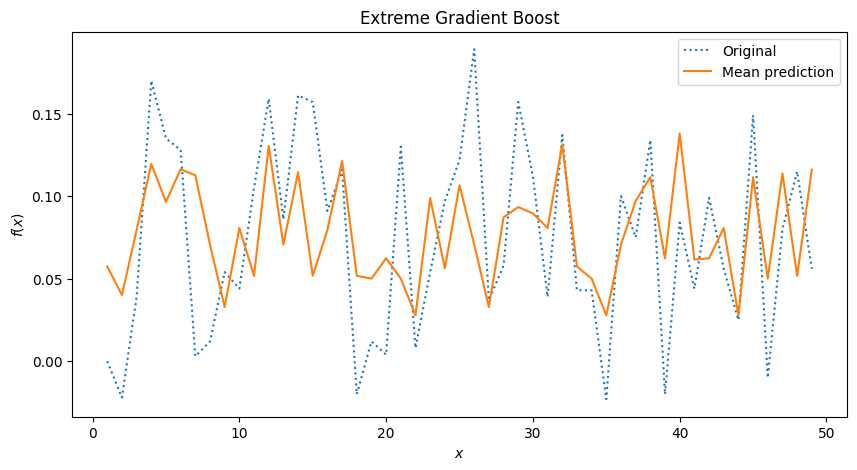

In [9]:
# 4. Make predictions
# Define a range of test points
X_test = testdata

# 5. Plot the results (optional but highly recommended)
length = range(1, len(prediction) + 1)
plt.figure(figsize=(10, 5))
plt.plot(length, testdata_labels, linestyle="dotted", label=r"Original")
#plt.errorbar(length.ravel(), y_train, noise_std, linestyle="None", color="tab:blue", marker=".", markersize=10, label="Observations")
plt.plot(length, prediction, label="Mean prediction")
# Fill the 95% confidence interval (mean +/- 2*std)
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("Extreme Gradient Boost")
plt.legend()
plt.show()